In [48]:
import requests
import pandas as pd

url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"

params = {
    "vs_currency": "usd",
    "days": 60
}

r = requests.get(url, params=params)

data = r.json()

prices = data["prices"]

df = pd.DataFrame(prices, columns=["time", "price"])

df["time"] = pd.to_datetime(df["time"], unit="ms")

df.head()  #获取行情数据

,time,price
0,2026-01-14 06:01:53.085,94961.633324
1,2026-01-14 07:02:03.644,94919.472518
2,2026-01-14 08:02:17.136,95174.502747
3,2026-01-14 09:02:09.666,94872.547000
4,2026-01-14 10:02:47.875,95048.539869


In [49]:
df["return"] = df["price"].pct_change()

df.head()   #每个时间点的涨跌幅

,time,price,return
0,2026-01-14 06:01:53.085,94961.633324,NaN
1,2026-01-14 07:02:03.644,94919.472518,-0.000444
2,2026-01-14 08:02:17.136,95174.502747,0.002687
3,2026-01-14 09:02:09.666,94872.547000,-0.003173
4,2026-01-14 10:02:47.875,95048.539869,0.001855


In [50]:
df["rolling_vol"] = df["return"].rolling(20).std()

df.tail()  #最近20个时间点波动率

,time,price,return,rolling_vol
1437,2026-03-15 02:08:20.452,71163.180109,0.002018,0.002256
1438,2026-03-15 03:11:37.154,71448.559270,0.004010,0.002067
1439,2026-03-15 04:09:38.581,71426.784612,-0.000305,0.002055
1440,2026-03-15 05:09:40.663,71540.165428,0.001587,0.002056
1441,2026-03-15 06:02:34.000,71506.161675,-0.000475,0.002052


In [51]:
exposure = 100000

z = 1.65

df["rolling_var"] = exposure * df["rolling_vol"] * z

df.tail() #rolling VaR

,time,price,return,rolling_vol,rolling_var
1437,2026-03-15 02:08:20.452,71163.180109,0.002018,0.002256,372.243309
1438,2026-03-15 03:11:37.154,71448.559270,0.004010,0.002067,341.001427
1439,2026-03-15 04:09:38.581,71426.784612,-0.000305,0.002055,339.102519
1440,2026-03-15 05:09:40.663,71540.165428,0.001587,0.002056,339.220341
1441,2026-03-15 06:02:34.000,71506.161675,-0.000475,0.002052,338.660179


In [52]:
balance = 20000

df["risk_ratio"] = exposure / balance

df.tail() #risk ritio

,time,price,return,rolling_vol,rolling_var,risk_ratio
1437,2026-03-15 02:08:20.452,71163.180109,0.002018,0.002256,372.243309,5.0
1438,2026-03-15 03:11:37.154,71448.559270,0.004010,0.002067,341.001427,5.0
1439,2026-03-15 04:09:38.581,71426.784612,-0.000305,0.002055,339.102519,5.0
1440,2026-03-15 05:09:40.663,71540.165428,0.001587,0.002056,339.220341,5.0
1441,2026-03-15 06:02:34.000,71506.161675,-0.000475,0.002052,338.660179,5.0


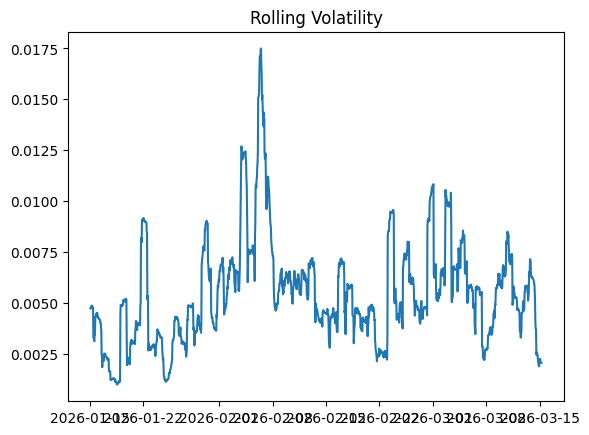

In [53]:
import matplotlib.pyplot as plt

plt.plot(df["time"], df["rolling_vol"])

plt.title("Rolling Volatility")

plt.show()

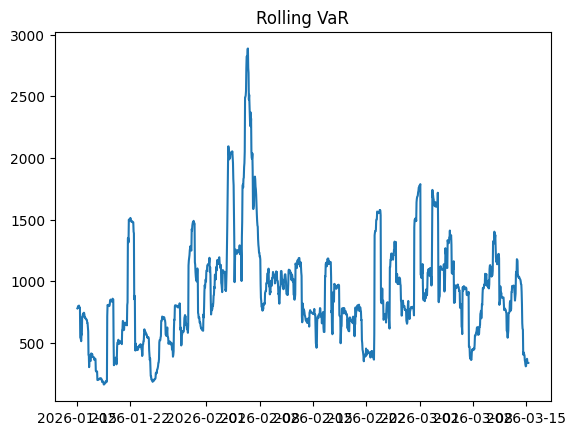

In [54]:
plt.plot(df["time"], df["rolling_var"])

plt.title("Rolling VaR")

plt.show()

In [55]:
threshold = 5000

df["alert"] = df["rolling_var"] > threshold

df.tail() #风险报警

,time,price,return,rolling_vol,rolling_var,risk_ratio,alert
1437,2026-03-15 02:08:20.452,71163.180109,0.002018,0.002256,372.243309,5.0,False
1438,2026-03-15 03:11:37.154,71448.559270,0.004010,0.002067,341.001427,5.0,False
1439,2026-03-15 04:09:38.581,71426.784612,-0.000305,0.002055,339.102519,5.0,False
1440,2026-03-15 05:09:40.663,71540.165428,0.001587,0.002056,339.220341,5.0,False
1441,2026-03-15 06:02:34.000,71506.161675,-0.000475,0.002052,338.660179,5.0,False


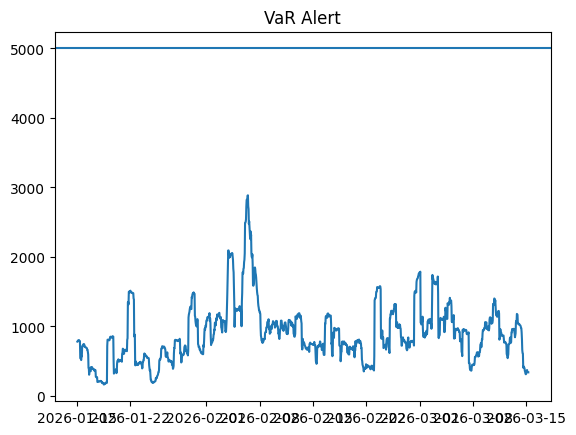

In [56]:
plt.plot(df["time"], df["rolling_var"])

plt.axhline(5000)

plt.title("VaR Alert")

plt.show()

In [57]:
import numpy as np

accounts = []

for i in range(20):

    exposure = np.random.randint(10000, 200000)

    balance = np.random.randint(5000, 50000)

    accounts.append([i, exposure, balance])

acc_df = pd.DataFrame(accounts, columns=["account", "exposure", "balance"])

acc_df["risk_ratio"] = acc_df["exposure"] / acc_df["balance"]

acc_df  #多账户风险率

,account,exposure,balance,risk_ratio
0,0,108713,26091,4.166686
1,1,36994,7749,4.774035
2,2,84131,48960,1.718362
3,3,52275,20209,2.586719
4,4,15103,45921,0.328891
5,5,173221,5119,33.838836
6,6,180155,22950,7.849891
7,7,149618,29342,5.099107
8,8,58704,49827,1.178156
9,9,156378,10033,15.586365


In [58]:
whale = acc_df[acc_df["exposure"] > 150000]

whale #whale monitor

,account,exposure,balance,risk_ratio
5,5,173221,5119,33.838836
6,6,180155,22950,7.849891
9,9,156378,10033,15.586365
15,15,176782,29102,6.074565
16,16,185180,10251,18.064579


In [59]:
high_risk = acc_df[acc_df["risk_ratio"] > 5]

high_risk

,account,exposure,balance,risk_ratio
5,5,173221,5119,33.838836
6,6,180155,22950,7.849891
7,7,149618,29342,5.099107
9,9,156378,10033,15.586365
12,12,99511,10112,9.840882
14,14,97555,6352,15.358155
15,15,176782,29102,6.074565
16,16,185180,10251,18.064579


In [60]:
latest_var = df["rolling_var"].iloc[-1]

acc_df["market_var"] = latest_var

acc_df["total_risk"] = acc_df["risk_ratio"] * latest_var

acc_df

,account,exposure,balance,risk_ratio,market_var,total_risk
0,0,108713,26091,4.166686,338.660179,1411.090568
1,1,36994,7749,4.774035,338.660179,1616.775668
2,2,84131,48960,1.718362,338.660179,581.940758
3,3,52275,20209,2.586719,338.660179,876.018647
4,4,15103,45921,0.328891,338.660179,111.382258
5,5,173221,5119,33.838836,338.660179,11459.866150
6,6,180155,22950,7.849891,338.660179,2658.445512
7,7,149618,29342,5.099107,338.660179,1726.864516
8,8,58704,49827,1.178156,338.660179,398.994664
9,9,156378,10033,15.586365,338.660179,5278.481156


In [61]:
acc_df["alert"] = acc_df["total_risk"] > 20000

acc_df

,account,exposure,balance,risk_ratio,market_var,total_risk,alert
0,0,108713,26091,4.166686,338.660179,1411.090568,False
1,1,36994,7749,4.774035,338.660179,1616.775668,False
2,2,84131,48960,1.718362,338.660179,581.940758,False
3,3,52275,20209,2.586719,338.660179,876.018647,False
4,4,15103,45921,0.328891,338.660179,111.382258,False
5,5,173221,5119,33.838836,338.660179,11459.866150,False
6,6,180155,22950,7.849891,338.660179,2658.445512,False
7,7,149618,29342,5.099107,338.660179,1726.864516,False
8,8,58704,49827,1.178156,338.660179,398.994664,False
9,9,156378,10033,15.586365,338.660179,5278.481156,False


In [62]:
alerts = acc_df[acc_df["alert"] == True]

alerts

,account,exposure,balance,risk_ratio,market_var,total_risk,alert


In [63]:
acc_df["whale"] = acc_df["exposure"] > 150000

acc_df  #whale + risk

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale
0,0,108713,26091,4.166686,338.660179,1411.090568,False,False
1,1,36994,7749,4.774035,338.660179,1616.775668,False,False
2,2,84131,48960,1.718362,338.660179,581.940758,False,False
3,3,52275,20209,2.586719,338.660179,876.018647,False,False
4,4,15103,45921,0.328891,338.660179,111.382258,False,False
5,5,173221,5119,33.838836,338.660179,11459.866150,False,True
6,6,180155,22950,7.849891,338.660179,2658.445512,False,True
7,7,149618,29342,5.099107,338.660179,1726.864516,False,False
8,8,58704,49827,1.178156,338.660179,398.994664,False,False
9,9,156378,10033,15.586365,338.660179,5278.481156,False,True


In [65]:
liquidation_threshold = 5 #风险率 > 5 就强平

In [66]:
acc_df["liquidation"] = acc_df["risk_ratio"] > liquidation_threshold

acc_df #true= 强平

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation
0,0,108713,26091,4.166686,338.660179,1411.090568,False,False,False
1,1,36994,7749,4.774035,338.660179,1616.775668,False,False,False
2,2,84131,48960,1.718362,338.660179,581.940758,False,False,False
3,3,52275,20209,2.586719,338.660179,876.018647,False,False,False
4,4,15103,45921,0.328891,338.660179,111.382258,False,False,False
5,5,173221,5119,33.838836,338.660179,11459.866150,False,True,True
6,6,180155,22950,7.849891,338.660179,2658.445512,False,True,True
7,7,149618,29342,5.099107,338.660179,1726.864516,False,False,True
8,8,58704,49827,1.178156,338.660179,398.994664,False,False,False
9,9,156378,10033,15.586365,338.660179,5278.481156,False,True,True


In [67]:
mark_price = df["price"].iloc[-1]

acc_df["mark_price"] = mark_price

acc_df["bankrupt_price"] = acc_df["mark_price"] * (1 - 1/acc_df["risk_ratio"])

acc_df

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,bankrupt_price
0,0,108713,26091,4.166686,338.660179,1411.090568,False,False,False,71506.161675,54344.761803
1,1,36994,7749,4.774035,338.660179,1616.775668,False,False,False,71506.161675,56528.023414
2,2,84131,48960,1.718362,338.660179,581.940758,False,False,False,71506.161675,29893.181018
3,3,52275,20209,2.586719,338.660179,876.018647,False,False,False,71506.161675,43862.584032
4,4,15103,45921,0.328891,338.660179,111.382258,False,False,False,71506.161675,-145909.878203
5,5,173221,5119,33.838836,338.660179,11459.866150,False,True,True,71506.161675,69393.022727
6,6,180155,22950,7.849891,338.660179,2658.445512,False,True,True,71506.161675,62396.970087
7,7,149618,29342,5.099107,338.660179,1726.864516,False,False,True,71506.161675,57482.890438
8,8,58704,49827,1.178156,338.660179,398.994664,False,False,False,71506.161675,10812.895155
9,9,156378,10033,15.586365,338.660179,5278.481156,False,True,True,71506.161675,66918.423501


In [68]:
acc_df["loss"] = acc_df["exposure"] * 0.1

acc_df

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,bankrupt_price,loss
0,0,108713,26091,4.166686,338.660179,1411.090568,False,False,False,71506.161675,54344.761803,10871.3
1,1,36994,7749,4.774035,338.660179,1616.775668,False,False,False,71506.161675,56528.023414,3699.4
2,2,84131,48960,1.718362,338.660179,581.940758,False,False,False,71506.161675,29893.181018,8413.1
3,3,52275,20209,2.586719,338.660179,876.018647,False,False,False,71506.161675,43862.584032,5227.5
4,4,15103,45921,0.328891,338.660179,111.382258,False,False,False,71506.161675,-145909.878203,1510.3
5,5,173221,5119,33.838836,338.660179,11459.866150,False,True,True,71506.161675,69393.022727,17322.1
6,6,180155,22950,7.849891,338.660179,2658.445512,False,True,True,71506.161675,62396.970087,18015.5
7,7,149618,29342,5.099107,338.660179,1726.864516,False,False,True,71506.161675,57482.890438,14961.8
8,8,58704,49827,1.178156,338.660179,398.994664,False,False,False,71506.161675,10812.895155,5870.4
9,9,156378,10033,15.586365,338.660179,5278.481156,False,True,True,71506.161675,66918.423501,15637.8


In [69]:
insurance_fund = 500000

total_loss = acc_df.loc[acc_df["liquidation"], "loss"].sum()

insurance_fund_after = insurance_fund - total_loss

insurance_fund_after

np.float64(378160.0)

In [70]:
adl_trigger = insurance_fund_after < 0

adl_trigger #true =  ADL

np.False_

In [72]:
tiers = [
    (50000, 0.05),
    (100000, 0.1),
    (200000, 0.2),
    (999999999, 0.3)
]  #limit, margin_rate

In [73]:
def get_margin_rate(exposure):

    for limit, rate in tiers:

        if exposure <= limit:
            return rate #根据仓位返回保证金比例

In [74]:
acc_df["margin_rate"] = acc_df["exposure"].apply(get_margin_rate)

acc_df #计算账户保证金率

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,bankrupt_price,loss,margin_rate
0,0,108713,26091,4.166686,338.660179,1411.090568,False,False,False,71506.161675,54344.761803,10871.3,0.20
1,1,36994,7749,4.774035,338.660179,1616.775668,False,False,False,71506.161675,56528.023414,3699.4,0.05
2,2,84131,48960,1.718362,338.660179,581.940758,False,False,False,71506.161675,29893.181018,8413.1,0.10
3,3,52275,20209,2.586719,338.660179,876.018647,False,False,False,71506.161675,43862.584032,5227.5,0.10
4,4,15103,45921,0.328891,338.660179,111.382258,False,False,False,71506.161675,-145909.878203,1510.3,0.05
5,5,173221,5119,33.838836,338.660179,11459.866150,False,True,True,71506.161675,69393.022727,17322.1,0.20
6,6,180155,22950,7.849891,338.660179,2658.445512,False,True,True,71506.161675,62396.970087,18015.5,0.20
7,7,149618,29342,5.099107,338.660179,1726.864516,False,False,True,71506.161675,57482.890438,14961.8,0.20
8,8,58704,49827,1.178156,338.660179,398.994664,False,False,False,71506.161675,10812.895155,5870.4,0.10
9,9,156378,10033,15.586365,338.660179,5278.481156,False,True,True,71506.161675,66918.423501,15637.8,0.20


In [75]:
acc_df["maintenance_margin"] = acc_df["exposure"] * acc_df["margin_rate"]

acc_df #maitenance margin

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,bankrupt_price,loss,margin_rate,maintenance_margin
0,0,108713,26091,4.166686,338.660179,1411.090568,False,False,False,71506.161675,54344.761803,10871.3,0.20,21742.60
1,1,36994,7749,4.774035,338.660179,1616.775668,False,False,False,71506.161675,56528.023414,3699.4,0.05,1849.70
2,2,84131,48960,1.718362,338.660179,581.940758,False,False,False,71506.161675,29893.181018,8413.1,0.10,8413.10
3,3,52275,20209,2.586719,338.660179,876.018647,False,False,False,71506.161675,43862.584032,5227.5,0.10,5227.50
4,4,15103,45921,0.328891,338.660179,111.382258,False,False,False,71506.161675,-145909.878203,1510.3,0.05,755.15
5,5,173221,5119,33.838836,338.660179,11459.866150,False,True,True,71506.161675,69393.022727,17322.1,0.20,34644.20
6,6,180155,22950,7.849891,338.660179,2658.445512,False,True,True,71506.161675,62396.970087,18015.5,0.20,36031.00
7,7,149618,29342,5.099107,338.660179,1726.864516,False,False,True,71506.161675,57482.890438,14961.8,0.20,29923.60
8,8,58704,49827,1.178156,338.660179,398.994664,False,False,False,71506.161675,10812.895155,5870.4,0.10,5870.40
9,9,156378,10033,15.586365,338.660179,5278.481156,False,True,True,71506.161675,66918.423501,15637.8,0.20,31275.60


In [76]:
acc_df["liquidation_v2"] = acc_df["balance"] < acc_df["maintenance_margin"]

acc_df #liquidation = balance < maintenance margin

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,bankrupt_price,loss,margin_rate,maintenance_margin,liquidation_v2
0,0,108713,26091,4.166686,338.660179,1411.090568,False,False,False,71506.161675,54344.761803,10871.3,0.20,21742.60,False
1,1,36994,7749,4.774035,338.660179,1616.775668,False,False,False,71506.161675,56528.023414,3699.4,0.05,1849.70,False
2,2,84131,48960,1.718362,338.660179,581.940758,False,False,False,71506.161675,29893.181018,8413.1,0.10,8413.10,False
3,3,52275,20209,2.586719,338.660179,876.018647,False,False,False,71506.161675,43862.584032,5227.5,0.10,5227.50,False
4,4,15103,45921,0.328891,338.660179,111.382258,False,False,False,71506.161675,-145909.878203,1510.3,0.05,755.15,False
5,5,173221,5119,33.838836,338.660179,11459.866150,False,True,True,71506.161675,69393.022727,17322.1,0.20,34644.20,True
6,6,180155,22950,7.849891,338.660179,2658.445512,False,True,True,71506.161675,62396.970087,18015.5,0.20,36031.00,True
7,7,149618,29342,5.099107,338.660179,1726.864516,False,False,True,71506.161675,57482.890438,14961.8,0.20,29923.60,True
8,8,58704,49827,1.178156,338.660179,398.994664,False,False,False,71506.161675,10812.895155,5870.4,0.10,5870.40,False
9,9,156378,10033,15.586365,338.660179,5278.481156,False,True,True,71506.161675,66918.423501,15637.8,0.20,31275.60,True


In [77]:
acc_df[[
    "account",
    "exposure",
    "balance",
    "risk_ratio",
    "liquidation",
    "liquidation_v2"
]]

,account,exposure,balance,risk_ratio,liquidation,liquidation_v2
0,0,108713,26091,4.166686,False,False
1,1,36994,7749,4.774035,False,False
2,2,84131,48960,1.718362,False,False
3,3,52275,20209,2.586719,False,False
4,4,15103,45921,0.328891,False,False
5,5,173221,5119,33.838836,True,True
6,6,180155,22950,7.849891,True,True
7,7,149618,29342,5.099107,True,True
8,8,58704,49827,1.178156,False,False
9,9,156378,10033,15.586365,True,True


In [78]:
shock = -0.2   # 跌20%

In [79]:
current_price = df["price"].iloc[-1]

shock_price = current_price * (1 + shock)

shock_price

np.float64(57204.92933990763)

In [80]:
acc_df["price"] = current_price

acc_df["shock_price"] = shock_price

acc_df["pnl"] = (shock_price - current_price) / current_price * acc_df["exposure"]

acc_df["equity_after_shock"] = acc_df["balance"] + acc_df["pnl"]

acc_df #after shock

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,bankrupt_price,loss,margin_rate,maintenance_margin,liquidation_v2,price,shock_price,pnl,equity_after_shock
0,0,108713,26091,4.166686,338.660179,1411.090568,False,False,False,71506.161675,54344.761803,10871.3,0.20,21742.60,False,71506.161675,57204.92934,-21742.6,4348.4
1,1,36994,7749,4.774035,338.660179,1616.775668,False,False,False,71506.161675,56528.023414,3699.4,0.05,1849.70,False,71506.161675,57204.92934,-7398.8,350.2
2,2,84131,48960,1.718362,338.660179,581.940758,False,False,False,71506.161675,29893.181018,8413.1,0.10,8413.10,False,71506.161675,57204.92934,-16826.2,32133.8
3,3,52275,20209,2.586719,338.660179,876.018647,False,False,False,71506.161675,43862.584032,5227.5,0.10,5227.50,False,71506.161675,57204.92934,-10455.0,9754.0
4,4,15103,45921,0.328891,338.660179,111.382258,False,False,False,71506.161675,-145909.878203,1510.3,0.05,755.15,False,71506.161675,57204.92934,-3020.6,42900.4
5,5,173221,5119,33.838836,338.660179,11459.866150,False,True,True,71506.161675,69393.022727,17322.1,0.20,34644.20,True,71506.161675,57204.92934,-34644.2,-29525.2
6,6,180155,22950,7.849891,338.660179,2658.445512,False,True,True,71506.161675,62396.970087,18015.5,0.20,36031.00,True,71506.161675,57204.92934,-36031.0,-13081.0
7,7,149618,29342,5.099107,338.660179,1726.864516,False,False,True,71506.161675,57482.890438,14961.8,0.20,29923.60,True,71506.161675,57204.92934,-29923.6,-581.6
8,8,58704,49827,1.178156,338.660179,398.994664,False,False,False,71506.161675,10812.895155,5870.4,0.10,5870.40,False,71506.161675,57204.92934,-11740.8,38086.2
9,9,156378,10033,15.586365,338.660179,5278.481156,False,True,True,71506.161675,66918.423501,15637.8,0.20,31275.60,True,71506.161675,57204.92934,-31275.6,-21242.6


In [81]:
acc_df["liquidation_stress"] = (
    acc_df["equity_after_shock"] < acc_df["maintenance_margin"]
)

acc_df

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,bankrupt_price,loss,margin_rate,maintenance_margin,liquidation_v2,price,shock_price,pnl,equity_after_shock,liquidation_stress
0,0,108713,26091,4.166686,338.660179,1411.090568,False,False,False,71506.161675,54344.761803,10871.3,0.20,21742.60,False,71506.161675,57204.92934,-21742.6,4348.4,True
1,1,36994,7749,4.774035,338.660179,1616.775668,False,False,False,71506.161675,56528.023414,3699.4,0.05,1849.70,False,71506.161675,57204.92934,-7398.8,350.2,True
2,2,84131,48960,1.718362,338.660179,581.940758,False,False,False,71506.161675,29893.181018,8413.1,0.10,8413.10,False,71506.161675,57204.92934,-16826.2,32133.8,False
3,3,52275,20209,2.586719,338.660179,876.018647,False,False,False,71506.161675,43862.584032,5227.5,0.10,5227.50,False,71506.161675,57204.92934,-10455.0,9754.0,False
4,4,15103,45921,0.328891,338.660179,111.382258,False,False,False,71506.161675,-145909.878203,1510.3,0.05,755.15,False,71506.161675,57204.92934,-3020.6,42900.4,False
5,5,173221,5119,33.838836,338.660179,11459.866150,False,True,True,71506.161675,69393.022727,17322.1,0.20,34644.20,True,71506.161675,57204.92934,-34644.2,-29525.2,True
6,6,180155,22950,7.849891,338.660179,2658.445512,False,True,True,71506.161675,62396.970087,18015.5,0.20,36031.00,True,71506.161675,57204.92934,-36031.0,-13081.0,True
7,7,149618,29342,5.099107,338.660179,1726.864516,False,False,True,71506.161675,57482.890438,14961.8,0.20,29923.60,True,71506.161675,57204.92934,-29923.6,-581.6,True
8,8,58704,49827,1.178156,338.660179,398.994664,False,False,False,71506.161675,10812.895155,5870.4,0.10,5870.40,False,71506.161675,57204.92934,-11740.8,38086.2,False
9,9,156378,10033,15.586365,338.660179,5278.481156,False,True,True,71506.161675,66918.423501,15637.8,0.20,31275.60,True,71506.161675,57204.92934,-31275.6,-21242.6,True


In [82]:
total_loss = acc_df.loc[
    acc_df["liquidation_stress"],
    "exposure"
].sum()

total_loss

np.int64(1947467)

In [83]:
insurance_fund = 500000

insurance_after = insurance_fund - total_loss

insurance_after

np.int64(-1447467)

In [84]:
adl_stress = insurance_after < 0

adl_stress

np.True_

In [85]:
liquid_count = acc_df["liquidation_stress"].sum()

liquid_count

np.int64(15)

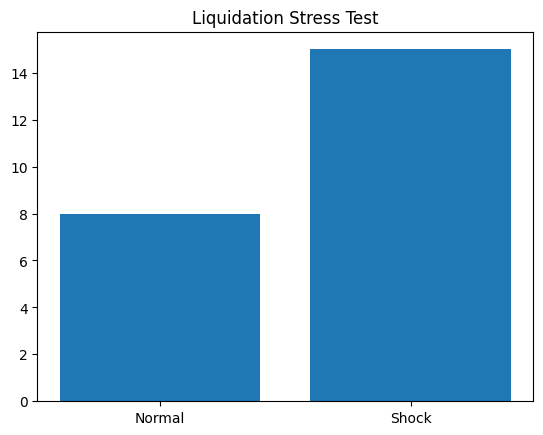

In [86]:
labels = ["Normal", "Shock"]

values = [
    acc_df["liquidation"].sum(),
    acc_df["liquidation_stress"].sum()
]

import matplotlib.pyplot as plt

plt.bar(labels, values)

plt.title("Liquidation Stress Test")

plt.show()

In [87]:
summary = {}

summary["price"] = df["price"].iloc[-1]

summary["rolling_vol"] = df["rolling_vol"].iloc[-1]

summary["rolling_var"] = df["rolling_var"].iloc[-1]

summary["total_accounts"] = len(acc_df)

summary["high_risk"] = (acc_df["risk_ratio"] > 5).sum()

summary["liquidations"] = acc_df["liquidation_v2"].sum()

summary["stress_liquidations"] = acc_df["liquidation_stress"].sum()

summary["insurance_left"] = insurance_after

summary["adl"] = adl_stress

summary  #Dashboard Data

{'price': np.float64(71506.16167488453),
 'rolling_vol': np.float64(0.0020524859318444967),
 'rolling_var': np.float64(338.6601787543419),
 'total_accounts': 20,
 'high_risk': np.int64(8),
 'liquidations': np.int64(7),
 'stress_liquidations': np.int64(15),
 'insurance_left': np.int64(-1447467),
 'adl': np.True_}

In [88]:
summary_df = pd.DataFrame(summary, index=[0])

summary_df

,price,rolling_vol,rolling_var,total_accounts,high_risk,liquidations,stress_liquidations,insurance_left,adl
0,71506.161675,0.002052,338.660179,20,8,7,15,-1447467,True


In [89]:
summary["whales"] = (acc_df["exposure"] > 150000).sum()

summary

{'price': np.float64(71506.16167488453),
 'rolling_vol': np.float64(0.0020524859318444967),
 'rolling_var': np.float64(338.6601787543419),
 'total_accounts': 20,
 'high_risk': np.int64(8),
 'liquidations': np.int64(7),
 'stress_liquidations': np.int64(15),
 'insurance_left': np.int64(-1447467),
 'adl': np.True_,
 'whales': np.int64(5)}

In [90]:
summary["alerts"] = acc_df["alert"].sum()

summary

{'price': np.float64(71506.16167488453),
 'rolling_vol': np.float64(0.0020524859318444967),
 'rolling_var': np.float64(338.6601787543419),
 'total_accounts': 20,
 'high_risk': np.int64(8),
 'liquidations': np.int64(7),
 'stress_liquidations': np.int64(15),
 'insurance_left': np.int64(-1447467),
 'adl': np.True_,
 'whales': np.int64(5),
 'alerts': np.int64(0)}

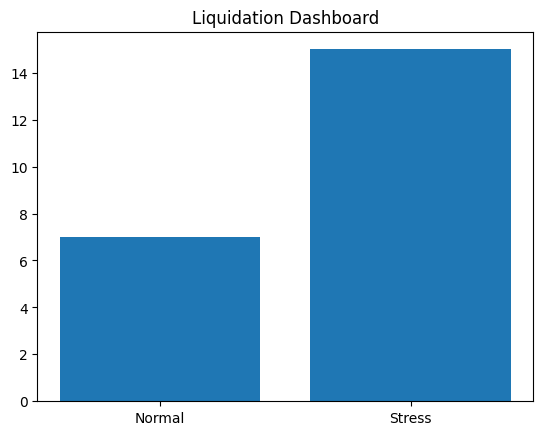

In [91]:
import matplotlib.pyplot as plt

labels = ["Normal", "Stress"]

values = [
    acc_df["liquidation_v2"].sum(),
    acc_df["liquidation_stress"].sum()
]

plt.bar(labels, values)

plt.title("Liquidation Dashboard")

plt.show()

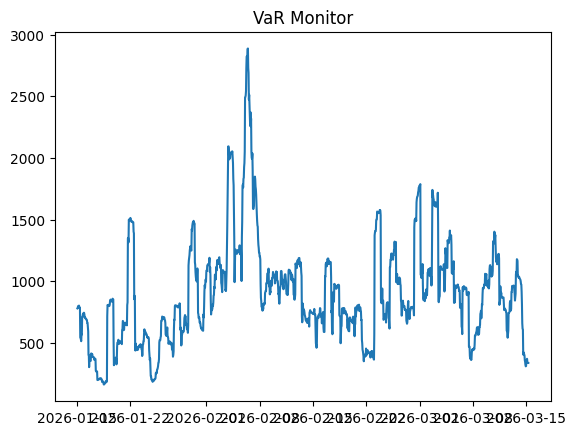

In [92]:
plt.plot(df["time"], df["rolling_var"])

plt.title("VaR Monitor")

plt.show()

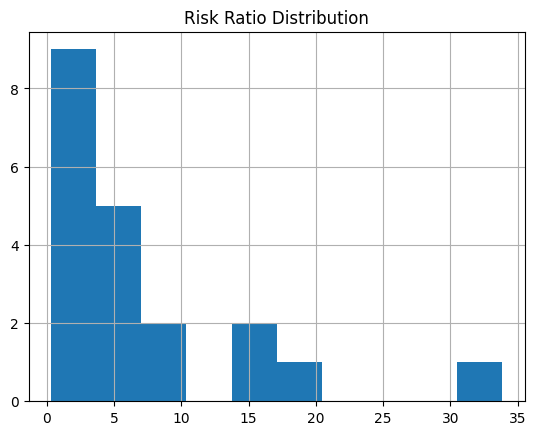

In [93]:
acc_df["risk_ratio"].hist()

plt.title("Risk Ratio Distribution")

plt.show()

In [95]:
acc_df.columns

Index(['account', 'exposure', 'balance', 'risk_ratio', 'market_var',
       'total_risk', 'alert', 'whale', 'liquidation', 'mark_price',
       'bankrupt_price', 'loss', 'margin_rate', 'maintenance_margin',
       'liquidation_v2', 'price', 'shock_price', 'pnl', 'equity_after_shock',
       'liquidation_stress'],
      dtype='object')

In [96]:
acc_df["adl"] = False

if adl_stress:
    acc_df.loc[acc_df["risk_ratio"] > 4, "adl"] = True

acc_df.head()

,account,exposure,balance,risk_ratio,market_var,total_risk,alert,whale,liquidation,mark_price,...,loss,margin_rate,maintenance_margin,liquidation_v2,price,shock_price,pnl,equity_after_shock,liquidation_stress,adl
0,0,108713,26091,4.166686,338.660179,1411.090568,False,False,False,71506.161675,...,10871.3,0.20,21742.60,False,71506.161675,57204.92934,-21742.6,4348.4,True,True
1,1,36994,7749,4.774035,338.660179,1616.775668,False,False,False,71506.161675,...,3699.4,0.05,1849.70,False,71506.161675,57204.92934,-7398.8,350.2,True,True
2,2,84131,48960,1.718362,338.660179,581.940758,False,False,False,71506.161675,...,8413.1,0.10,8413.10,False,71506.161675,57204.92934,-16826.2,32133.8,False,False
3,3,52275,20209,2.586719,338.660179,876.018647,False,False,False,71506.161675,...,5227.5,0.10,5227.50,False,71506.161675,57204.92934,-10455.0,9754.0,False,False
4,4,15103,45921,0.328891,338.660179,111.382258,False,False,False,71506.161675,...,1510.3,0.05,755.15,False,71506.161675,57204.92934,-3020.6,42900.4,False,False


In [97]:
acc_df[
    [
        "account",
        "exposure",
        "balance",
        "risk_ratio",
        "margin_rate",
        "liquidation_v2",
        "liquidation_stress",
        "adl"
    ]
]

,account,exposure,balance,risk_ratio,margin_rate,liquidation_v2,liquidation_stress,adl
0,0,108713,26091,4.166686,0.20,False,True,True
1,1,36994,7749,4.774035,0.05,False,True,True
2,2,84131,48960,1.718362,0.10,False,False,False
3,3,52275,20209,2.586719,0.10,False,False,False
4,4,15103,45921,0.328891,0.05,False,False,False
5,5,173221,5119,33.838836,0.20,True,True,True
6,6,180155,22950,7.849891,0.20,True,True,True
7,7,149618,29342,5.099107,0.20,True,True,True
8,8,58704,49827,1.178156,0.10,False,False,False
9,9,156378,10033,15.586365,0.20,True,True,True
